<a href="https://colab.research.google.com/github/tutikobi/am-trabalho-pratico-noshows/blob/main/02_modelagem_avancada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático da Disciplina CMP263 - Aprendizagem de Máquina

# Alunos:
* Arthur Armando Kobielski Barreto
* Nikolas Lacerda Santos
* Rafael Silveira Machado

## Sumário

- [Trabalho Prático da Disciplina CMP263 - Aprendizagem de Máquina](#scrollTo=U8TVPf1FE_tR)
- [Introdução](#scrollTo=qn-2oBoKFIbx)
- [Configuração Inicial do Projeto](#scrollTo=79nGkt-3vK0I)
- [Análise Exploratória dos Dados](#scrollTo=5fV3JBjlvmhL)
  - [Análise das Variáveis Numéricas](#scrollTo=x_YQQfzJctzs)
  - [Análise das Variáveis Categóricas](#scrollTo=4Za3pD6wFkpR)
  - [Dados Faltantes e Duplicados](#scrollTo=HYaSEfctxVVL)
  - [Análise da Variável Alvo](#scrollTo=yHYPy2dL2t5e)
- [Pré-Processamento dos Dados](#scrollTo=nKy85gzVxtpu)
  - [Limpeza dos Dados](#scrollTo=Qyldh9kw3XM6)
  - [Conversão dos Dados](#scrollTo=ox15ufia3njb)
  - [Codificação de Variáveis Categóricas](#scrollTo=UCdqB_Rm5CZl)
  - [Estado Final do Dataset](#scrollTo=pQnXim9958UO)
- [Modelagem](#scrollTo=A0V_zshA6yQZ)
  - [Escalonamento das Variáveis](#scrollTo=lSLwejDo7ZJL)
  - [Validação Cruzada](#scrollTo=yoTXgqjGg8yZ)
  - [Modelo de Base](#scrollTo=2VulEo2Z8JSy)
    - [Avaliação do modelo base](#scrollTo=eF5iM6sz8vqf)
  - [Modelo Random Forest](#scrollTo=6x9jnCd88_Uo)
  - [Modelo XGBoost](#scrollTo=oAI1w_vo9T7_)
- [Otimização de Hiperparâmetros](#scrollTo=7M81jG9SA0PW)
- [Avaliação dos Modelos](#scrollTo=_9G7Ini1Bwlj)
  - [Comparação dos Modelos com AUC-ROC Média](#scrollTo=91c98647)
  - [Curva ROC para Todos os Modelos](#scrollTo=720f12bc)
  - [Avaliação Final do Melhor Modelo](#scrollTo=aed38289)
    - [Ajuste do Limiar de Decisão](#scrollTo=df44404e)
- [Análise dos Resultados](#scrollTo=L3kNv0T3D_HI)
- [Explicabilidade: Análise de Importância das Variáveis](#scrollTo=WDBAVeCe9yEc)
- [SHAP (Shapley Additive exPlanations)](#scrollTo=td6hM6pGzPi7)
  - [Gráfico de Dependências](#scrollTo=9taLFUVbIL6p)
  - [Análise Individual de Pacientes](#scrollTo=x8n-B7LaIloF)
- [Clusterização](#scrollTo=bsiBC18xY0mz)
- [Inclusão dos Clusters como Atributo](#scrollTo=NacDc74U0VcI)
- [Conclusão](#scrollTo=4rAy2g-7guPB)
  - [O Impacto da Clusterização](#scrollTo=jeutwcJKgxEZ)
  - [Resumo da Modelagem](#scrollTo=jeutwcJKgxEZ)

# Introdução

Este trabalho tem como objetivo analisadar um conjunto de dados sobre o não comparecimento de pacientes em consultas médicas e aplicar técnicas de Machine Learning para prever se um paciente irá faltar a consulta ou não. O Dataset possui 110.527 consultas médicas e 14 variáveis associadas.

Link do Dataset: https://www.kaggle.com/datasets/joniarroba/noshowappointments/data

# Configuração Inicial do Projeto
- Nessa etapa vamos importar o dataset e as bibliotecas usadas para a exploração e análise dos dados

> ⚠️ Para executar este notebook, adicione o zip do dataset aos arquivos do google colab com o seguinte nome: 'archive' (nome padrão que vem do kaggle)

In [70]:
import os
import zipfile
import pandas as pd

zip_path = '/content/archive.zip' # Altere para o nome exato do seu zip se for diferente
extract_dir = '/content/data'

print("Extraindo arquivo ZIP...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

arquivos_extraidos = os.listdir(extract_dir)
print(f"Arquivos encontrados após extração: {arquivos_extraidos}")

arquivos_csv = [f for f in arquivos_extraidos if f.endswith('.csv')]

if len(arquivos_csv) == 0:
    print("ERRO: O arquivo .zip não contém nenhum CSV! Verifique o arquivo baixado do Kaggle.")
else:
    csv_file = arquivos_csv[0]
    df = pd.read_csv(os.path.join(extract_dir, csv_file))
    print("SUCESSO: Dataset carregado com sucesso!")

Extraindo arquivo ZIP...
Arquivos encontrados após extração: ['KaggleV2-May-2016.csv']
SUCESSO: Dataset carregado com sucesso!


In [71]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Análise Exploratória dos Dados
- Nesta etapa vamos explorar o Dataset e visualizar alguns dados. O objetivo é entender melhor os dados e o cenário no qual estamos lidando

In [72]:
df.shape

(110527, 14)

* O Dataset possui 110527 linhas e 14 colunas (atributos).

Visão das 5 primeiras linhas:

In [73]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


Atributos do dataset:

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


* **Colunas de identificação**: (PatientId, AppointmentID).
* **Variáveis temporais**: (ScheduledDay, AppointmentDay).
* **Variáveis demográficas e de saúde**: (Gender, Age, Neighbourhood, Scholarship, Hipertension, Diabetes, Alcoholism, Handcap).
* **Variável de alertas**: (SMS_received).
* **Variável alvo**: No-show (Se o paciente não compareceu: "Yes" ou "No").

Análise estatística dos atributos numéricos e categóricos:

## Análise das Variáveis Numéricas

In [75]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


Notamos que o Handcap é uma variavel de 0 à 4, na descrição de atributos do dataset no Kaggle, este atributo está como booleano, acreditamos que é um erro na descrição. Vamos assumir isso como o número de limitações/incapacidades/deficiências do paciente e vamos trata-lá posteriormente.

In [76]:
df['Handcap'].value_counts()

,count
Handcap,
0,108286
1,2042
2,183
3,13
4,3


* Idade Inconsistente: O valor mínimo de Age é -1.
* Coluna Handcap: Apresenta valores [0, 1, 2, 3, 4]. Isso indica que ela pode representar o número de limitações do paciente.

## Análise das Variáveis Categóricas

In [77]:
df.describe(include='O')

,Gender,ScheduledDay,AppointmentDay,Neighbourhood,No-show
count,110527,110527,110527,110527,110527
unique,2,103549,27,81,2
top,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,JARDIM CAMBURI,No
freq,71840,24,4692,7717,88208


* A coluna No-show está como string ("Yes"/"No"). Precisamos convertê-la para o padrão numérico

In [78]:
df['Gender'].value_counts()

,count
Gender,
F,71840
M,38687


In [79]:
df['ScheduledDay'].value_counts()

,count
ScheduledDay,
2016-05-06T07:09:54Z,24
2016-05-06T07:09:53Z,23
2016-04-25T17:18:27Z,22
2016-04-25T17:17:46Z,22
2016-04-25T17:17:23Z,19
...,...
2016-05-09T10:17:48Z,1
2016-05-02T09:50:06Z,1
2016-05-13T14:28:22Z,1


- As colunas ScheduledDay (dia que agendou) é uma data em formato de texto que não será efetiva em um modelo de Machine Learning. Vamos explorar estratégias de uso desse atributo posteriormente.

In [80]:
df['AppointmentDay'].value_counts()

,count
AppointmentDay,
2016-06-06T00:00:00Z,4692
2016-05-16T00:00:00Z,4613
2016-05-09T00:00:00Z,4520
2016-05-30T00:00:00Z,4514
2016-06-08T00:00:00Z,4479
2016-05-11T00:00:00Z,4474
2016-06-01T00:00:00Z,4464
2016-06-07T00:00:00Z,4416
2016-05-12T00:00:00Z,4394


- Assim como a coluna ScheduledDay, a coluna AppointmentDay (dia da consulta) também é uma data em formato de texto e não serve para o modelo. Discutiremos o seu uso na próxima etapa.

In [81]:
df['Neighbourhood'].value_counts()

,count
Neighbourhood,
JARDIM CAMBURI,7717
MARIA ORTIZ,5805
RESISTÊNCIA,4431
JARDIM DA PENHA,3877
ITARARÉ,3514
...,...
ILHA DO BOI,35
ILHA DO FRADE,10
AEROPORTO,8


- Temos 81 bairros diferentes

## Dados Faltantes e Duplicados

In [82]:
print("Valores Nulos por Coluna:")
print(df.isnull().sum())

print("\nLinhas Duplicadas:", df.duplicated().sum())

Valores Nulos por Coluna:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

Linhas Duplicadas: 0


* Em um primeiro momento, o dataset está limpo em termos de valores nulos, e não há linhas duplicadas.

## Análise da Variável Alvo

Distribuição do Target:
No-show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64


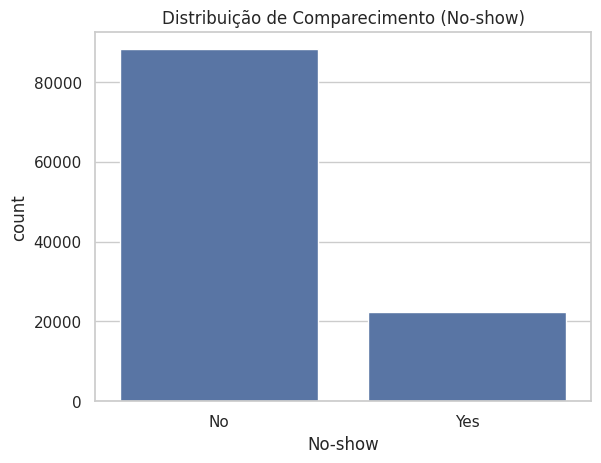

In [83]:
target_counts = df['No-show'].value_counts(normalize=True) * 100
print(f"Distribuição do Target:\n{target_counts}")

sns.countplot(data=df, x='No-show')
plt.title('Distribuição de Comparecimento (No-show)')
plt.show()

* Cerca de 80% dos pacientes comparecem ("No") e 20% faltam ("Yes"). Temos um dataset desbalanceado

# Pré-Processamento dos Dados

Agora que conhecemos os problemas e as características dos dados, vamos prepará-los para os modelos.

## Limpeza dos Dados
- Remoção da linha identificada na análise exploratória de dados com a idade negativa de -1.

In [84]:
df = df[df['Age'] >= 0]

## Conversão dos Dados

Conforme analisado na exploração, notamos que o ScheduledDay (dia que agendou) e AppointmentDay (dia da consulta) em formato de texto não servirão para o modelo.

Vamos utilizar a estratégia de unificar essas datas em uma variável númerica nova, equivalente a diferença de dias entre o agendamento e a consulta. Além de útil pelo conceito inicial de que um tempo maior pode vir a fazer um paciente faltar ela também fica preparada no formato correto para o treinamento de modelos

In [85]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df['WaitingDays'] = (df['AppointmentDay'].dt.normalize() - df['ScheduledDay'].dt.normalize()).dt.days

print("Consultas com dias negativos:", (df['WaitingDays'] < 0).sum())

df = df[df['WaitingDays'] >= 0]

Consultas com dias negativos: 5


Além do tempo entre as consultas, vamos extrair o dia da semana que cai a consulta, para identificar se existe algum fator onde o dia contribui para a falta ou não da consulta.

In [86]:
df['AppointmentDayOfWeek'] = df['AppointmentDay'].dt.dayofweek # 0=Segunda, 6=Domingo

Distribuição do novo atributo WaitingDays

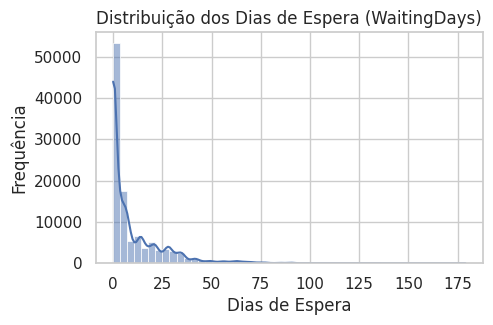

In [87]:
plt.figure(figsize=(5, 3))
sns.histplot(df['WaitingDays'], bins=50, kde=True)
plt.title('Distribuição dos Dias de Espera (WaitingDays)')
plt.xlabel('Dias de Espera')
plt.ylabel('Frequência')
plt.show()

Nossa suspeita inicial parece se confirmar pela distribuição dos dados

Relação entre 'AppointmentDayOfWeek' em e a variável alvo 'No-show'

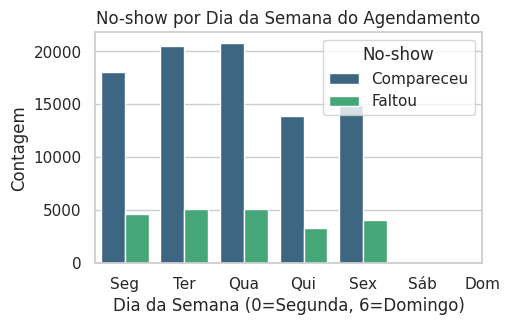

In [88]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='AppointmentDayOfWeek', hue='No-show', palette='viridis')
plt.title('No-show por Dia da Semana do Agendamento')
plt.xlabel('Dia da Semana (0=Segunda, 6=Domingo)')
plt.ylabel('Contagem')
plt.legend(title='No-show', labels=['Compareceu', 'Faltou'])
plt.xticks(ticks=range(7), labels=['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])
plt.show()

Agora vamos tratar a coluna Handcap, aqui vamos usar a estratégia de transformá-la em binária (0 = sem limitações, 1 = com limitações)

Note que uma minoria possui limitações maiores que 0, então é seguro usar a nossa estratégia binária

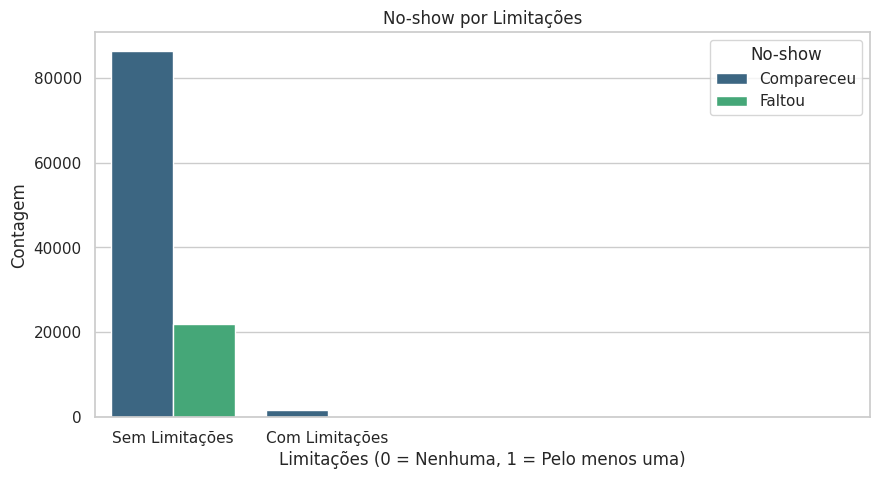

In [89]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Handcap', hue='No-show', palette='viridis')
plt.title('No-show por Limitações')
plt.xlabel('Limitações (0 = Nenhuma, 1 = Pelo menos uma)')
plt.ylabel('Contagem')
plt.legend(title='No-show', labels=['Compareceu', 'Faltou'])
plt.xticks(ticks=[0, 1], labels=['Sem Limitações', 'Com Limitações'])
plt.show()

In [90]:
df['Handcap'] = df['Handcap'].apply(lambda x: 1 if x > 0 else 0)
print("Nova distribuição da coluna Handcap:")
print(df['Handcap'].value_counts())

Nova distribuição da coluna Handcap:
Handcap
0    108282
1      2239
Name: count, dtype: int64


 Antes de remover o PatientId, vamos ordenar o dataset de forma cronológica e criar atributos contínuos como 'TotalPreviousAppointments' e 'HistoricalNoShowRate'.

 O objetivo é identificar se pacientes que já faltaram antes têm probabilidade muito maior de faltar novamente.

/tmp/ipykernel_455/2929613376.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['1 Consulta', 'Mais de 1 Consulta'], y=[uma_consulta, mais_de_uma], palette='viridis')


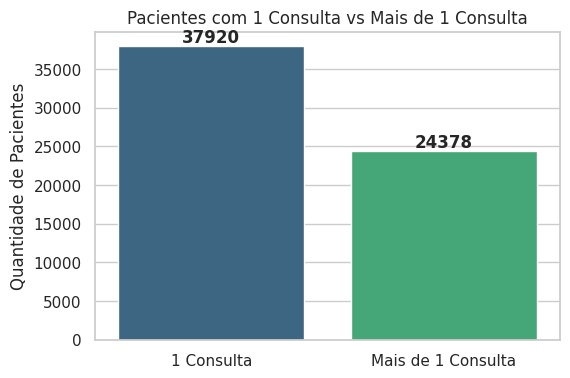

Total de pacientes únicos: 62298
Pacientes com apenas 1 consulta: 37920 (60.9%)
Pacientes com mais de 1 consulta: 24378 (39.1%)


In [91]:
consultas_por_paciente = df['PatientId'].value_counts()

uma_consulta = (consultas_por_paciente == 1).sum()
mais_de_uma = (consultas_por_paciente > 1).sum()

plt.figure(figsize=(6, 4))
sns.barplot(x=['1 Consulta', 'Mais de 1 Consulta'], y=[uma_consulta, mais_de_uma], palette='viridis')
plt.title('Pacientes com 1 Consulta vs Mais de 1 Consulta')
plt.ylabel('Quantidade de Pacientes')

for i, v in enumerate([uma_consulta, mais_de_uma]):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.show()

total_pacientes = len(consultas_por_paciente)
print(f"Total de pacientes únicos: {total_pacientes}")
print(f"Pacientes com apenas 1 consulta: {uma_consulta} ({(uma_consulta/total_pacientes)*100:.1f}%)")
print(f"Pacientes com mais de 1 consulta: {mais_de_uma} ({(mais_de_uma/total_pacientes)*100:.1f}%)")

Como temos um número relevante de pacientes com mais de uma consulta essa estratégia parece fazer sentido

In [92]:
df = df.sort_values(by='ScheduledDay')

# Criar uma variável numérica temporária para facilitar os cálculos
df['NoShowNum'] = (df['No-show'] == 'Yes').astype(int)

# Contar quantas consultas o paciente já teve antes da atual (count começa em 0)
df['TotalPreviousAppointments'] = df.groupby('PatientId').cumcount()

# Contar quantas faltas o paciente teve antes da atual
df['PreviousAppointmentsCount'] = df.groupby('PatientId')['NoShowNum'].cumsum()
df['PreviousAppointments'] = df['PreviousAppointmentsCount'] - df['NoShowNum']

# Calcular a taxa de falta histórica (PreviousAppointments / TotalPreviousAppointments)
df['HistoricalNoShowRate'] = (df['PreviousAppointments'] / df['TotalPreviousAppointments']).fillna(0)

# Limpar as colunas temporárias
df = df.drop(columns=['NoShowNum', 'PreviousAppointmentsCount', 'PreviousAppointments'])

# Validando o resultado: Exibir o histórico de um paciente com várias consultas
paciente_exemplo = df[df['TotalPreviousAppointments'] > 2]['PatientId'].iloc[0]
display(df[df['PatientId'] == paciente_exemplo][['PatientId', 'ScheduledDay', 'No-show', 'TotalPreviousAppointments', 'HistoricalNoShowRate']])

,PatientId,ScheduledDay,No-show,TotalPreviousAppointments,HistoricalNoShowRate
69879,5.995927e+12,2016-03-01 11:54:58+00:00,No,0,0.000000
46698,5.995927e+12,2016-03-01 11:55:45+00:00,No,1,0.000000
71303,5.995927e+12,2016-03-01 11:57:47+00:00,No,2,0.000000
66720,5.995927e+12,2016-03-03 10:14:15+00:00,Yes,3,0.000000
963,5.995927e+12,2016-04-01 08:29:54+00:00,No,4,0.250000
46759,5.995927e+12,2016-04-29 08:17:36+00:00,Yes,5,0.200000
4839,5.995927e+12,2016-05-13 08:59:44+00:00,No,6,0.333333
97119,5.995927e+12,2016-05-31 08:57:11+00:00,No,7,0.285714


IDs de pacientes e de consultas são gerados aleatoriamente e não terão relevância nesta análise. Também descartaremos as colunas originais de data que já alteramos.

In [93]:
df_clean = df.drop(columns=['PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay'])

## Codificação de Variáveis Categóricas

Utilizaremos uma estratégia simples de apenas codificar os atributos categóricos

In [94]:
df_clean['No-show'] = df_clean['No-show'].map({'No': 0, 'Yes': 1})
df_clean['Gender'] = df_clean['Gender'].map({'F': 0, 'M': 1})

Para a variável Neighbourhood, fazer One-Hot Encoding cria 81 novas colunas. Como pretendemos usar modelos baseados em árvore (Decision Tree, Random Forest e XGBoost) isso não se faz necessário.

O Target Encoding substitui o nome do bairro pela média da variável alvo para aquele bairro. Se no bairro 'JARDIM CAMBURI' 25% dos pacientes faltam (Target = 1), o valor de 'JARDIM CAMBURI' passará a ser 0.25. [Link](https://medium.com/@heitornunesrosa/o-que-%C3%A9-target-encoding-e-como-aplic%C3%A1-lo-85996e1bf00d)

Vamos manter o Neighbourhood original por enquanto. Faremos o Target Encoding logo após a separação de treino/teste para evitar Data Leakage.

## Estado Final do Dataset

Dataset após o pré-processamento dos dados

In [95]:
display(df_clean.head())
print("\nFormato Final do Dataset:", df_clean.shape)

,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,WaitingDays,AppointmentDayOfWeek,TotalPreviousAppointments,HistoricalNoShowRate
3764,0,51,RESISTÊNCIA,0,0,0,0,0,1,0,176,2,0,0.0
46292,1,34,VILA RUBIM,0,1,0,0,0,1,1,151,0,0,0.0
102795,0,27,SÃO CRISTÓVÃO,1,0,0,0,0,1,1,179,4,0,0.0
102797,0,48,MARUÍPE,0,1,1,0,0,1,0,179,4,0,0.0
102796,0,80,SÃO CRISTÓVÃO,0,1,1,0,0,1,0,179,4,0,0.0



Formato Final do Dataset: (110521, 14)


# Modelagem
Após ter os nossos dados limpos, transformados e finalizados na etapa anterior, avançaremos para as fases de modelagem e validação.

Primeiro, separamos as variáveis preditoras da nossa variável alvo (No-show):

In [96]:
X = df_clean.drop(columns=['No-show'])
y = df_clean['No-show']

Como o nosso dataset tem uma dependência temporal (pacientes têm histórico cronológico de consultas), precisamos garantir que o modelo não "veja o futuro" para prever o passado (*Time Leakage*). Para isso, vamos dividir os dados respeitando a ordem cronológica, separando os primeiros 80% para treino e os 20% finais para teste, sem embaralhar.

In [97]:
from sklearn.model_selection import train_test_split

# Split cronológico (shuffle=False). Os dados já foram ordenados por 'ScheduledDay' na etapa de pré-processamento.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False
)

Agora que estamos com os dados de treinamento separados, vamos implementar a pendência de target encoding analisada no pré-processamente para o atributo 'Neighbourhood'

In [98]:
!pip install category_encoders imbalanced-learn

print(f"Formato do Treino: {X_train.shape}")
print(f"Formato do Teste: {X_test.shape}")

Formato do Treino: (88416, 13)
Formato do Teste: (22105, 13)


## Escalonamento das Variáveis

Como estamos utilizando algoritmos baseados em Árvore, essa etapa não se faz necessária.

## Validação Cruzada

Para que a comparação entre os modelos seja estatisticamente honesta e respeite o fator temporal, precisamos garantir que o particionamento dos dados seja consistente.

Faremos isso instanciando um objeto `TimeSeriesSplit` no lugar do `StratifiedKFold`. Isso garante que em cada iteração (fold), o conjunto de validação será sempre futuro em relação ao conjunto de treinamento, evitando o vazamento temporal (*Time Leakage*) na etapa de validação.

In [99]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_validate
from sklearn.metrics import classification_report, f1_score, roc_auc_score, make_scorer

cv_compartilhado = TimeSeriesSplit(n_splits=5)

class_weights_dict = 'balanced'
scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()

metricas = {
    'f1_macro': 'f1_macro',
    'f1_classe_1': make_scorer(f1_score, pos_label=1), # Foco em prever quem vai faltar
    'auc_roc': 'roc_auc',
    'pr_auc': 'average_precision'
}

In [100]:
resultados_cv = {}

## Modelo de Base

Vamos começar utilizando uma árvore de decisão: Um modelo simples, rápido e interpretável para usar como ponto de partida.

Para lidar com o desbalanceamento sem precisar criar dados sintéticos (como SMOTE), utilizaremos o class_weight='balanced'. Ele penaliza mais severamente o erro na classe minoritária.

In [101]:
from sklearn.tree import DecisionTreeClassifier
from category_encoders import TargetEncoder
from imblearn.pipeline import Pipeline as ImbPipeline

dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)

dt_pipeline = ImbPipeline([
    ('target_encoder', TargetEncoder(cols=['Neighbourhood'], smoothing=10)),
    ('model', dt_model)
])

print("Avaliando a Árvore de Decisão...")
scores_dt = cross_validate(dt_pipeline, X_train, y_train, cv=cv_compartilhado, scoring=metricas, n_jobs=-1 )

dt_pipeline.fit(X_train, y_train)

Avaliando a Árvore de Decisão...


Pipeline(steps=[('target_encoder', TargetEncoder(cols=['Neighbourhood'])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

### Avaliação do modelo base

Em problemas desbalanceados, a métrica de Acurácia não é ideal. Se um modelo disser que "ninguém vai faltar a consulta", ele terá 80% de acurácia, mas será um modelo fraco. Para nossa análise, vamos usar o F1-Score e Recall, junto com uma Matriz de Confusão para visualização.

In [102]:
resultados_cv['Árvore de Decisão'] = {
    'F1-Score (Macro) Média': scores_dt['test_f1_macro'].mean(),
    'F1-Score (Macro) Std': scores_dt['test_f1_macro'].std(),
    'F1-Score (Classe 1/Faltou) Média': scores_dt['test_f1_classe_1'].mean(),
    'AUC-ROC Média': scores_dt['test_auc_roc'].mean()
}

resultados_cv['Árvore de Decisão']

{'F1-Score (Macro) Média': np.float64(0.5424983160719694),
 'F1-Score (Macro) Std': np.float64(0.01365633588674498),
 'F1-Score (Classe 1/Faltou) Média': np.float64(0.2815053011425218),
 'AUC-ROC Média': np.float64(0.5453368502067184)}

## Modelo Random Forest

Random forest é um algoritmo de aprendizado de máquina que combina resultados de saída de múltiplas árvores de decisão para alcançar um único resultado [Link](https://www.ibm.com/br-pt/think/topics/random-forest) . Usaremos ele como uma opção por sua facilidade de uso e flexibilidade.

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_base = RandomForestClassifier(class_weight=class_weights_dict, random_state=42, n_jobs=-1)

rf_pipeline = ImbPipeline([
    ('target_encoder', TargetEncoder(cols=['Neighbourhood'], smoothing=10)),
    ('model', rf_base)
])

print("Avaliando a Random Forest...")
scores_rf = cross_validate(rf_pipeline, X_train, y_train, cv=cv_compartilhado, scoring=metricas, n_jobs=-1 )

Avaliando a Random Forest...


In [104]:
resultados_cv['Random Forest (Base)'] = {
    'F1-Score (Macro) Média': scores_rf['test_f1_macro'].mean(),
    'F1-Score (Macro) Std': scores_rf['test_f1_macro'].std(),
    'F1-Score (Classe 1/Faltou) Média': scores_rf['test_f1_classe_1'].mean(),
    'AUC-ROC Média': scores_rf['test_auc_roc'].mean()
}

resultados_cv['Random Forest (Base)']

{'F1-Score (Macro) Média': np.float64(0.5320607990602767),
 'F1-Score (Macro) Std': np.float64(0.0038028690786043986),
 'F1-Score (Classe 1/Faltou) Média': np.float64(0.19119558810765006),
 'AUC-ROC Média': np.float64(0.6759365893316762)}

## Modelo XGBoost
O XGBoost (eXtreme Gradient Boosting) é uma biblioteca de aprendizado de máquina de código aberto que utiliza árvores de decisão com gradient boosting, um algoritmo de boosting de aprendizado supervisionado que emprega gradiente descendente. [Link](https://www.ibm.com/br-pt/think/topics/xgboost)

In [105]:
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight_value,
    eval_metric='logloss')

xgb_pipeline = ImbPipeline([
    ('target_encoder', TargetEncoder(cols=['Neighbourhood'], smoothing=10)),
    ('model', xgb_model)
])

print("Avaliando o XGBoost...")
scores_xgb = cross_validate(xgb_pipeline, X_train, y_train, cv=cv_compartilhado, scoring=metricas, n_jobs=-1 )

Avaliando o XGBoost...


In [106]:
resultados_cv['XGBoost (Base)'] = {
    'F1-Score (Macro) Média': scores_xgb['test_f1_macro'].mean(),
    'F1-Score (Macro) Std': scores_xgb['test_f1_macro'].std(),
    'F1-Score (Classe 1/Faltou) Média': scores_xgb['test_f1_classe_1'].mean(),
    'AUC-ROC Média': scores_xgb['test_auc_roc'].mean()
}

resultados_cv['XGBoost (Base)']

{'F1-Score (Macro) Média': np.float64(0.5846856531863288),
 'F1-Score (Macro) Std': np.float64(0.015960760983699647),
 'F1-Score (Classe 1/Faltou) Média': np.float64(0.40390402187901353),
 'AUC-ROC Média': np.float64(0.6986410499247363)}

# Otimização de Hiperparâmetros

Realizamos o RandomizedSearchCV acoplado ao nosso objeto de validação cruzada. Vamos otimizar a Random Forest e o XGBoost.

O RandomizedSearchCV foi escolhido em relação ao GridSearch por uma questão de otimização de recursos.

In [107]:
from sklearn.model_selection import RandomizedSearchCV

> ⚠️ O código abaixo leva em torno de 15 minutos para executar com n=10 interações no ambiente free do colab . Usamos n=50 nesse experimento, utilizando o colab pro.



In [108]:
rf_param_dist = {
    "model__n_estimators": [10, 50, 100],
    "model__max_depth": [5, 7, 8, 10],
    "model__min_samples_split": [2, 5, 10, 20, 50],
    "model__min_samples_leaf": [1, 2, 4, 8, 16],
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "model__class_weight": [class_weights_dict],
    "model__bootstrap": [True],
    "model__criterion": ["gini", "entropy", "log_loss"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=50,
    scoring='average_precision',
    cv=cv_compartilhado,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf_model = rf_search.best_estimator_

print("Melhores parâmetros RF:", rf_search.best_params_)

print("Avaliando a Random Forest escolhida..")
cv_results = cross_validate(best_rf_model, X_train, y_train, cv=cv_compartilhado, scoring=metricas, n_jobs=-1)

Melhores parâmetros RF: {'model__n_estimators': 100, 'model__min_samples_split': 50, 'model__min_samples_leaf': 16, 'model__max_features': 0.5, 'model__max_depth': 8, 'model__criterion': 'log_loss', 'model__class_weight': 'balanced', 'model__bootstrap': True}
Avaliando a Random Forest escolhida..


In [109]:
resultados_cv['Random Forest (Best)'] = {
    'F1-Score (Macro) Média': cv_results['test_f1_macro'].mean(),
    'F1-Score (Macro) Std': cv_results['test_f1_macro'].std(),
    'F1-Score (Classe 1/Faltou) Média': cv_results['test_f1_classe_1'].mean(),
    'AUC-ROC Média': cv_results['test_auc_roc'].mean()
}

resultados_cv['Random Forest (Best)']

{'F1-Score (Macro) Média': np.float64(0.5938406909709363),
 'F1-Score (Macro) Std': np.float64(0.02185680113640937),
 'F1-Score (Classe 1/Faltou) Média': np.float64(0.39960622364071274),
 'AUC-ROC Média': np.float64(0.7110011884140771)}

> ⚠️ O código abaixo leva em torno de 10 minutos para executar com n=10 interações no ambiente free do colab . Usamos n=50 nesse experimento, utilizando o colab pro.

In [110]:
xgb_param_dist = {
    "model__n_estimators": [200, 300, 500, 800],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__learning_rate": [0.005, 0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_weight": [1, 5, 10, 20],
    "model__gamma": [0, 0.5, 1, 2, 5],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 2, 5, 10],
    "model__scale_pos_weight": [scale_pos_weight_value]
}

xgb_tune = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=50,
    scoring='average_precision',
    cv=cv_compartilhado,
    random_state=42,
    n_jobs=-1
)

xgb_tune.fit(X_train, y_train)

best_xgb = xgb_tune.best_estimator_

print("Melhores parâmetros XGBoost:", xgb_tune.best_params_)

print("Avaliando o XGBoost escolhido...")
cv_results = cross_validate(best_xgb, X_train, y_train, cv=cv_compartilhado, scoring=metricas, n_jobs=-1)

Melhores parâmetros XGBoost: {'model__subsample': 0.8, 'model__scale_pos_weight': np.float64(3.4924546516945276), 'model__reg_lambda': 5, 'model__reg_alpha': 0, 'model__n_estimators': 800, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__gamma': 5, 'model__colsample_bytree': 1.0}
Avaliando o XGBoost escolhido...


In [111]:
resultados_cv['XGBoost (Best)'] = {
    'F1-Score (Macro) Média': cv_results['test_f1_macro'].mean(),
    'F1-Score (Macro) Std': cv_results['test_f1_macro'].std(),
    'F1-Score (Classe 1/Faltou) Média': cv_results['test_f1_classe_1'].mean(),
    'AUC-ROC Média': cv_results['test_auc_roc'].mean()
}

resultados_cv['XGBoost (Best)']

{'F1-Score (Macro) Média': np.float64(0.5801940136468671),
 'F1-Score (Macro) Std': np.float64(0.030407285308419046),
 'F1-Score (Classe 1/Faltou) Média': np.float64(0.4299989811401247),
 'AUC-ROC Média': np.float64(0.7166952148546082)}

# Avaliação dos Modelos

In [112]:
df_comparacao = pd.DataFrame(resultados_cv).T
df_comparacao = df_comparacao.sort_values(by='AUC-ROC Média', ascending=False)
display(df_comparacao.round(4))

,F1-Score (Macro) Média,F1-Score (Macro) Std,F1-Score (Classe 1/Faltou) Média,AUC-ROC Média
XGBoost (Best),0.5802,0.0304,0.4300,0.7167
Random Forest (Best),0.5938,0.0219,0.3996,0.7110
XGBoost (Base),0.5847,0.0160,0.4039,0.6986
Random Forest (Base),0.5321,0.0038,0.1912,0.6759
Árvore de Decisão,0.5425,0.0137,0.2815,0.5453


### Comparação dos Modelos com ROC-AUC

/tmp/ipykernel_455/1180869880.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_comparacao.index, y='AUC-ROC Média', data=df_comparacao, palette='magma')


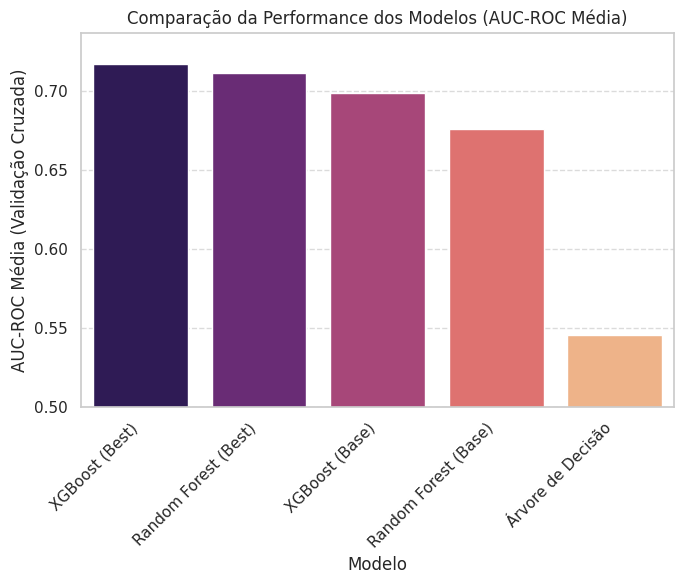

In [113]:
plt.figure(figsize=(7, 6))
sns.barplot(x=df_comparacao.index, y='AUC-ROC Média', data=df_comparacao, palette='magma')
plt.title('Comparação da Performance dos Modelos (AUC-ROC Média)')
plt.xlabel('Modelo')
plt.ylabel('AUC-ROC Média (Validação Cruzada)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.5, df_comparacao['AUC-ROC Média'].max() + 0.02)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Curva ROC para Todos os Modelos

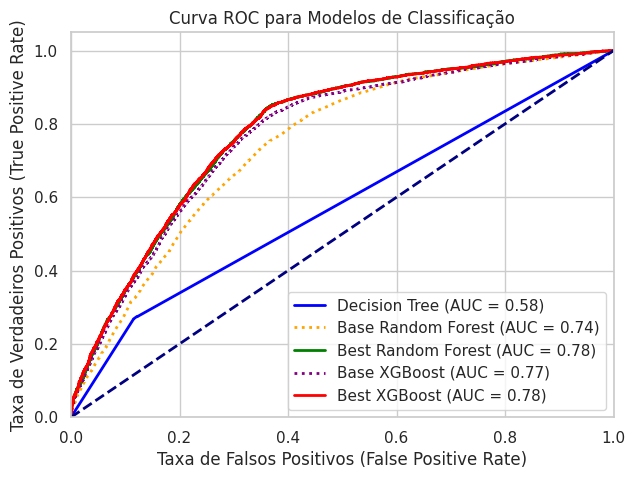

In [114]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 5))

dt_pipeline.fit(X_train, y_train)
y_pred_proba_lr = dt_pipeline.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Decision Tree (AUC = {roc_auc_lr:.2f})')

# Base Random Forest
rf_pipeline.fit(X_train, y_train)
y_pred_proba_rf_base = rf_pipeline.predict_proba(X_test)[:, 1]
fpr_rf_base, tpr_rf_base, _ = roc_curve(y_test, y_pred_proba_rf_base)
roc_auc_rf_base = auc(fpr_rf_base, tpr_rf_base)
plt.plot(fpr_rf_base, tpr_rf_base, color='orange', lw=2, linestyle=':', label=f'Base Random Forest (AUC = {roc_auc_rf_base:.2f})')

# Best Random Forest
best_rf_model.fit(X_train, y_train)
y_pred_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Best Random Forest (AUC = {roc_auc_rf:.2f})')

# Base XGBoost
xgb_pipeline.fit(X_train, y_train)
y_pred_proba_xgb_base = xgb_pipeline.predict_proba(X_test)[:, 1]
fpr_xgb_base, tpr_xgb_base, _ = roc_curve(y_test, y_pred_proba_xgb_base)
roc_auc_xgb_base = auc(fpr_xgb_base, tpr_xgb_base)
plt.plot(fpr_xgb_base, tpr_xgb_base, color='purple', lw=2, linestyle=':', label=f'Base XGBoost (AUC = {roc_auc_xgb_base:.2f})')

# Best XGBoost
best_xgb.fit(X_train, y_train)
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2, label=f'Best XGBoost (AUC = {roc_auc_xgb:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (False Positive Rate)')
plt.ylabel('Taxa de Verdadeiros Positivos (True Positive Rate)')
plt.title('Curva ROC para Modelos de Classificação')
plt.legend(loc='lower right')
plt.show()

### Curva Precision-Recall e Average Precision (PR-AUC)

Como o nosso dataset é altamente desbalanceado (80% comparece, 20% falta), a curva ROC pode passar uma falsa sensação de excelente performance, pois ela contabiliza os verdadeiros negativos (que são fáceis de prever por serem a maioria).

A **Curva Precision-Recall (PR-AUC ou Average Precision)** é muito mais rigorosa, pois não leva em conta os Verdadeiros Negativos, focando apenas no quão bem o modelo identifica as faltas.

Average Precision (PR-AUC) - Árvore de Decisão: 0.1520
Average Precision (PR-AUC) - Base Random Forest: 0.2611
Average Precision (PR-AUC) - Best Random Forest: 0.3155
Average Precision (PR-AUC) - Base XGBoost: 0.2981
Average Precision (PR-AUC) - Best XGBoost: 0.3196


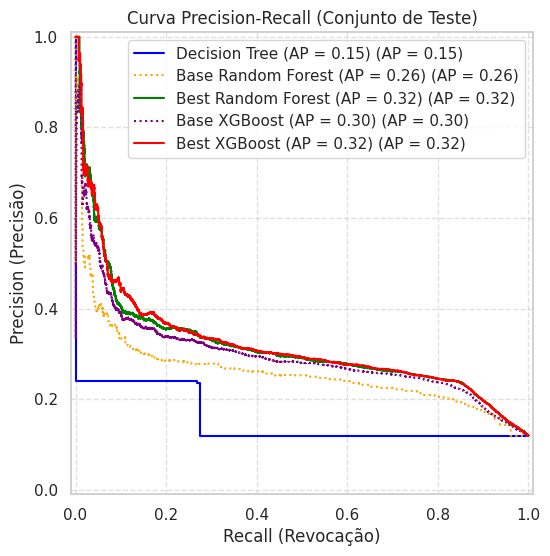

In [115]:
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Calculando o Average Precision (PR-AUC) para os modelos no conjunto de teste

ap_dt = average_precision_score(y_test, y_pred_proba_lr)
ap_rf_base = average_precision_score(y_test, y_pred_proba_rf_base)
ap_rf = average_precision_score(y_test, y_pred_proba_rf)
ap_xgb_base = average_precision_score(y_test, y_pred_proba_xgb_base)
ap_xgb = average_precision_score(y_test, y_pred_proba_xgb)

print(f"Average Precision (PR-AUC) - Árvore de Decisão: {ap_dt:.4f}")
print(f"Average Precision (PR-AUC) - Base Random Forest: {ap_rf_base:.4f}")
print(f"Average Precision (PR-AUC) - Best Random Forest: {ap_rf:.4f}")
print(f"Average Precision (PR-AUC) - Base XGBoost: {ap_xgb_base:.4f}")
print(f"Average Precision (PR-AUC) - Best XGBoost: {ap_xgb:.4f}")

plt.figure(figsize=(9, 6))

PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba_lr, name=f"Decision Tree (AP = {ap_dt:.2f})", ax=plt.gca(), color='blue')
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba_rf_base, name=f"Base Random Forest (AP = {ap_rf_base:.2f})", ax=plt.gca(), color='orange', linestyle=':')
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba_rf, name=f"Best Random Forest (AP = {ap_rf:.2f})", ax=plt.gca(), color='green')
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba_xgb_base, name=f"Base XGBoost (AP = {ap_xgb_base:.2f})", ax=plt.gca(), color='purple', linestyle=':')
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba_xgb, name=f"Best XGBoost (AP = {ap_xgb:.2f})", ax=plt.gca(), color='red')

plt.title('Curva Precision-Recall (Conjunto de Teste)')
plt.xlabel('Recall (Revocação)')
plt.ylabel('Precision (Precisão)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Avaliação Final do Melhor Modelo

O melhor modelo foi o XGBoost Otimizado, ele atingiu as melhores métricas em treino.

In [116]:
y_pred_xgb_best = best_xgb.predict(X_test)
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

f1_macro_test = f1_score(y_test, y_pred_xgb_best, average='macro')
f1_class1_test = f1_score(y_test, y_pred_xgb_best, pos_label=1)
roc_auc_test = roc_auc_score(y_test, y_pred_proba_xgb)
pr_auc_test = average_precision_score(y_test, y_pred_proba_xgb)

metricas_teste = {
    'Métrica': ['F1-Macro', 'F1 Classe 1', 'ROC-AUC', 'PR-AUC'],
    'Score (Teste)': [f1_macro_test, f1_class1_test, roc_auc_test, pr_auc_test]
}

df_metricas_teste = pd.DataFrame(metricas_teste)
display(df_metricas_teste.round(4))


,Métrica,Score (Teste)
0,F1-Macro,0.6207
1,F1 Classe 1,0.3754
2,ROC-AUC,0.7834
3,PR-AUC,0.3196


Nos dados de teste, o modelo atingiu um **F1-Score (Classe 1)** de 0.3760, **ROC-AUC** de 0.7834 e **PR-AUC** de 0.32.

No teste, a ROC-AUC ficou em 0,7834. Isso indica desempenho acima do acaso, mas a PR-AUC de 0,32 mostra que o modelo ainda gera muitos falsos positivos quando tentamos capturar mais faltas.

A **PR-AUC de 0.32** (considerando que a linha de base aleatória para este dataset seria em torno de 0.20, referente à proporção de faltas) indica que, embora o modelo seja superior a um palpite aleatório, existe um forte "trade-off" (compromisso) entre precisão e recall. Ou seja, a confiança (precisão) do modelo cai rapidamente à medida que tentamos abranger mais pacientes faltantes.

Matematicamente, o limiar de decisão focado no F1-Score busca o melhor equilíbrio. Mas, na prática, pode gerar alertas falsos demais (baixa precisão, em torno de 31%). Capturamos a grande maioria dos faltantes (Recall alto), mas abrimos mão de sermos assertivos em cada alerta gerado. Por isso, a escolha de como agir sobre essas probabilidades deve estar alinhada com as regras de negócio.

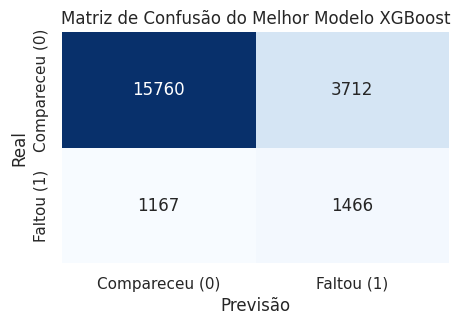

In [117]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_xgb_best = best_xgb.predict(X_test)
cm_xgb_best = confusion_matrix(y_test, y_pred_xgb_best)

plt.figure(figsize=(5, 3))
sns.heatmap(cm_xgb_best, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Compareceu (0)', 'Faltou (1)'],
            yticklabels=['Compareceu (0)', 'Faltou (1)'])
plt.title('Matriz de Confusão do Melhor Modelo XGBoost')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

### Ajuste do Limiar de Decisão
Como nosso problema é desbalanceado, o limiar padrão de 0.50 muitas vezes não é o ideal. Vamos usar a Curva Precision-Recall para encontrar o limiar ótimo que maximiza o F1-Score da Classe 1 (Faltou).

Limiar Ótimo Encontrado: 0.4415
F1-Score Máximo (Classe 1): 0.3841


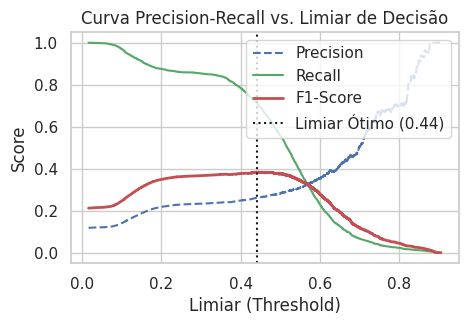

In [118]:
from sklearn.metrics import precision_recall_curve

y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

# Calcula Precision, Recall e os limiares correspondentes
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

f1_scores = np.divide(2 * (precision * recall), (precision + recall), out=np.zeros_like(precision), where=(precision + recall) != 0)

# Threshold focado em F1
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
max_f1 = f1_scores[optimal_idx]

print(f"Limiar Ótimo Encontrado: {optimal_threshold:.4f}")
print(f"F1-Score Máximo (Classe 1): {max_f1:.4f}")

plt.figure(figsize=(5, 3))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
plt.plot(thresholds, recall[:-1], 'g-', label='Recall')
plt.plot(thresholds, f1_scores[:-1], 'r-', linewidth=2, label='F1-Score')
plt.axvline(x=optimal_threshold, color='k', linestyle=':', label=f'Limiar Ótimo ({optimal_threshold:.2f})')
plt.title('Curva Precision-Recall vs. Limiar de Decisão')
plt.xlabel('Limiar (Threshold)')
plt.ylabel('Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()

Novo limiar e ver o impacto na nossa Matriz de Confusão.

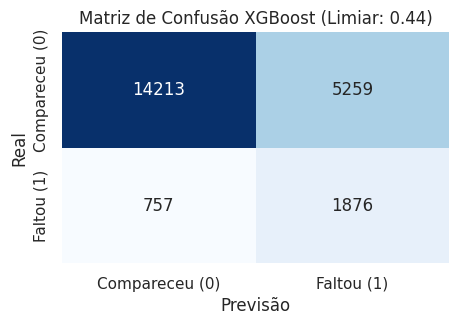

In [119]:
from sklearn.metrics import classification_report

y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

cm_optimal = confusion_matrix(y_test, y_pred_optimal)

plt.figure(figsize=(5, 3))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Compareceu (0)', 'Faltou (1)'],
            yticklabels=['Compareceu (0)', 'Faltou (1)'])
plt.title(f'Matriz de Confusão XGBoost (Limiar: {optimal_threshold:.2f})')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

In [120]:
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
import pandas as pd

f1_macro_opt = f1_score(y_test, y_pred_optimal, average='macro')
f1_class1_opt = f1_score(y_test, y_pred_optimal, pos_label=1)
roc_auc_opt = roc_auc_score(y_test, y_pred_proba)
pr_auc_opt = average_precision_score(y_test, y_pred_proba)

metricas_opt = {
    'Métrica': ['F1-Macro', 'F1 Classe 1', 'ROC-AUC', 'PR-AUC'],
    'Score (Limiar Ótimo)': [f1_macro_opt, f1_class1_opt, roc_auc_opt, pr_auc_opt]
}

df_metricas_opt = pd.DataFrame(metricas_opt)
display(df_metricas_opt.round(4))


,Métrica,Score (Limiar Ótimo)
0,F1-Macro,0.6047
1,F1 Classe 1,0.3841
2,ROC-AUC,0.7834
3,PR-AUC,0.3196


### Ajustando o Limiar com Foco no Recall

Em vez de otimizar o F1-Score (que busca o equilíbrio matemático), a clínica pode ter uma regra de negócio clara: **"Precisamos identificar pelo menos 75% dos pacientes que vão faltar"**.

Para isso, basta olhar para a nossa lista de Recalls calculada anteriormente e encontrar qual é o **limiar (threshold)** que garante esse valor.

Limiar necessário para atingir ~75.0% de Recall: 0.4195
Precisão que teremos com este limiar: 0.2533


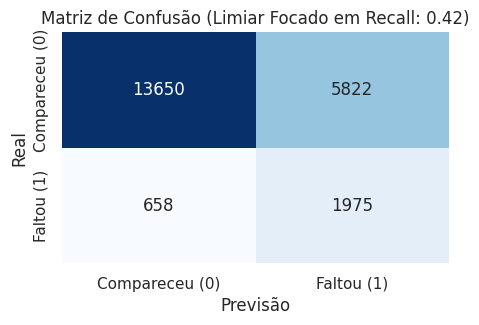

In [121]:
target_recall = 0.75

# Procura o índice onde o recall é mais próximo ou igual a 75%
idx_target_recall = np.where(recall >= target_recall)[0][-1]
threshold_target_recall = thresholds[idx_target_recall]

print(f"Limiar necessário para atingir ~{target_recall*100}% de Recall: {threshold_target_recall:.4f}")
print(f"Precisão que teremos com este limiar: {precision[idx_target_recall]:.4f}")

y_pred_high_recall = (y_pred_proba >= threshold_target_recall).astype(int)

cm_high_recall = confusion_matrix(y_test, y_pred_high_recall)

plt.figure(figsize=(5, 3))
sns.heatmap(cm_high_recall, annot=True, cmap='Blues', fmt='d', cbar=False,
            xticklabels=['Compareceu (0)', 'Faltou (1)'],
            yticklabels=['Compareceu (0)', 'Faltou (1)'])
plt.title(f'Matriz de Confusão (Limiar Focado em Recall: {threshold_target_recall:.2f})')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

# Análise dos Resultados

O modelo foi "pessimista". Na prática, o risco aqui dependeria da ação que a clínica pretende tomar. Se a clínica usar o modelo apenas para mandar um SMS ou email extra, o custo seria quase zero então ser pessimista se justificaria.
Mas se a clínica usar isso para agendar outra pessoa no mesmo horário, por exemplo, isso seria um resultado ruim, pois iria gerar um grande número de agendamento.

Impacto na Precisão (29.19%): Como o modelo está mais desconfiado, ele acaba errando mais ao prever que pessoas vão faltar quando, na verdade, elas comparecem. De cada 100 alertas de falta que o modelo dá agora, apenas cerca de 29 realmente faltarão.

# Explicabilidade: Análise de Importância das Variáveis

No nosso estudo, é importante entender as decisões do modelo, principalmente por se tratar da área da saúde. Vamos extrair isso do nosso modelo selecionado.

/tmp/ipykernel_455/3887830065.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')


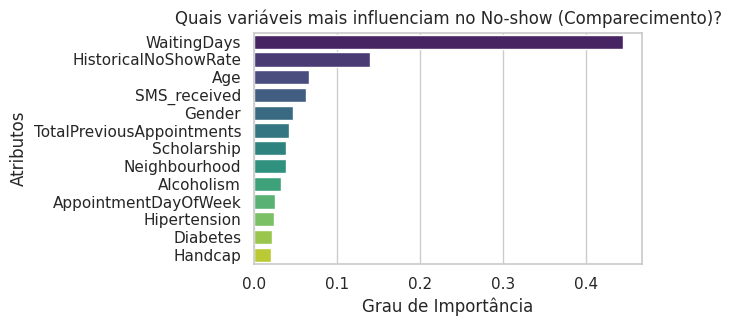

In [122]:
# Extrai a importância dos recursos do modelo dentro do pipeline
importances = best_xgb.named_steps['model'].feature_importances_
feature_names = X.columns

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(5, 3))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Quais variáveis mais influenciam no No-show (Comparecimento)?')
plt.xlabel('Grau de Importância')
plt.ylabel('Atributos')
plt.show()

O gráfico acima ilustra a importância global das variáveis calculada diretamente pela estrutura de árvores do XGBoost. Fica evidente que a variável `WaitingDays` (Tempo de Espera) é o fator mais decisivo para o modelo prever um absenteísmo. As variáveis `SMS_received` e `HistoricalNoShowRate` também têm destaque.

No entanto, este método possui uma limitação: ele apenas nos diz *quais* variáveis são mais acionadas no momento do corte das árvores, mas não nos diz *como* elas influenciam a decisão (se aumentam ou diminuem o risco). Para analisar a esse impacto, utilizamos o SHAP.

# SHAP (Shapley Additive exPlanations)

Vamos melhorar nossa análise usando o SHAP (Shapley Additive exPlanations) no XGBoost Otimizado para ter uma visão mais aprimorada de como cada variável afeta a probabilidade de um paciente faltar.

> ⚠️ O código abaixo leva em torno de 15 minutos para executar






Calculando os valores SHAP (isso pode levar um minuto)...

Gráfico gerado e salvo com sucesso em 'assets/shap_summary.png'!


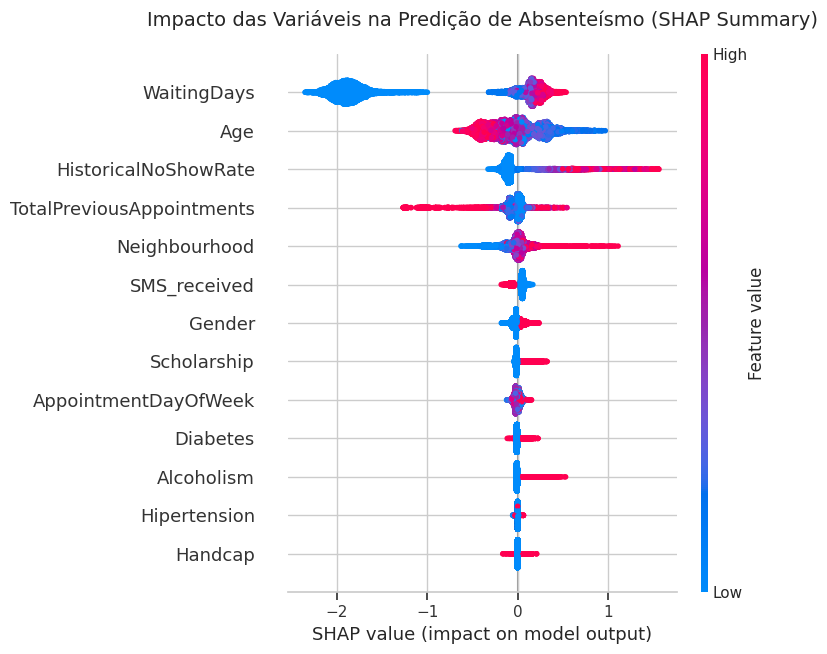

In [123]:
import shap
import matplotlib.pyplot as plt
import os

print("Calculando os valores SHAP (isso pode levar um minuto)...")

# Como usamos pipeline, precisamos extrair o modelo treinado interno e
# transformar os dados pelo TargetEncoder antes de passar pro SHAP
modelo_interno_xgb = best_xgb.named_steps['model']
target_encoder = best_xgb.named_steps['target_encoder']
X_test_shap = target_encoder.transform(X_test)

explainer = shap.TreeExplainer(modelo_interno_xgb)
shap_values = explainer.shap_values(X_test_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_shap, show=False)

plt.title('Impacto das Variáveis na Predição de Absenteísmo (SHAP Summary)', fontsize=14, pad=20)
plt.tight_layout()

if not os.path.exists('assets'):
    os.makedirs('assets')
plt.savefig('assets/shap_summary.png', dpi=300, bbox_inches='tight')

print("\nGráfico gerado e salvo com sucesso em 'assets/shap_summary.png'!")
plt.show()

- **WaitingDays:** Valores altos (pontos vermelhos) empurram fortemente a predição para a direita, aumentando drasticamente a chance de falta (No-show = 1). Consultas marcadas para o mesmo dia ou no dia seguinte (pontos azuis) têm um peso negativo massivo, indicando alto índice de comparecimento.
- **SMS_received:** Curiosamente, receber o SMS  tem um impacto que empurra a predição positivamente (aumentando a probabilidade de falta).
- **Age:** Pacientes mais jovens (pontos azuis) contribuem para um maior risco de falta. Pacientes idosos (pontos vermelhos) puxam a predição para o comparecimento.

## Gráfico de Dependências

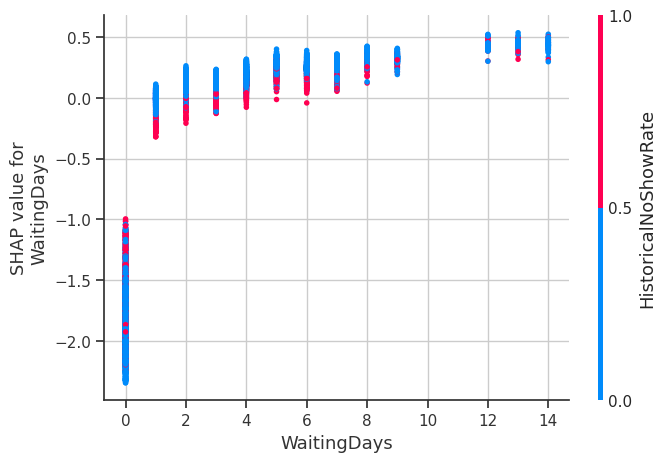

In [124]:
shap.dependence_plot(
    'WaitingDays',
    shap_values,
    X_test_shap
)

Observamos uma forte **relação não-linear**: o risco de falta aumenta consideravelmente nos primeiros dias de espera (a transição de 0 dias para 10 a 15 dias de espera). Depois dos 15 ou 20 dias, a curva tende a se estabilizar em um platô. Isso indica que, para o paciente, ter uma consulta marcada para daqui a 3 semanas ou para daqui a 2 meses apresenta praticamente o mesmo alto risco de esquecimento ou desistência.

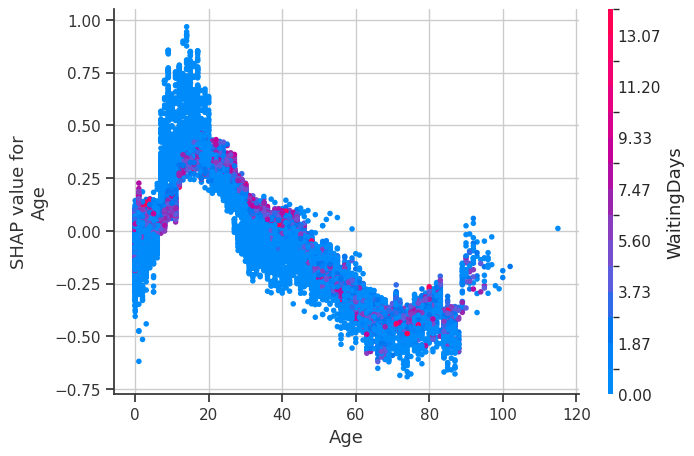

In [125]:
shap.dependence_plot(
    'Age',
    shap_values,
    X_test_shap
)

Aqui vemos claramente a faixa etária de risco. Pacientes entre **15 e 35 anos** tendem a ficar acima da linha do zero (aumentam a probabilidade de falta). A curva sofre uma queda acentuada a partir dos 50 anos, ficando predominantemente na região negativa, o que reforça que adultos mais velhos e idosos são significativamente mais assíduos em seus compromissos médicos do que jovens.

## Análise Individual de Pacientes

In [126]:
idx = 15

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_shap.iloc[idx]
)

In [127]:
idx = 150

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_shap.iloc[idx]
)

In [128]:
idx = 1500

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_shap.iloc[idx]
)


SHAP de Cascata para o Paciente (idx = 15)


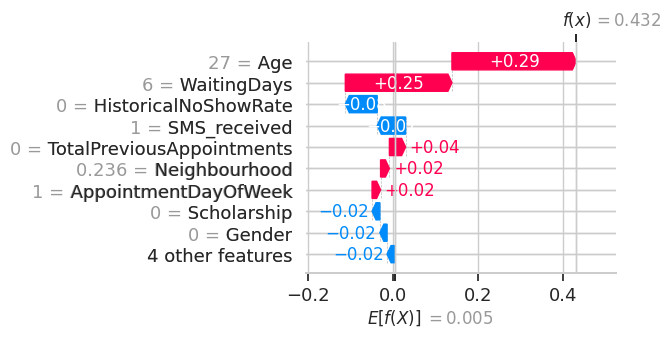


SHAP de Cascata para o Paciente (idx = 150)


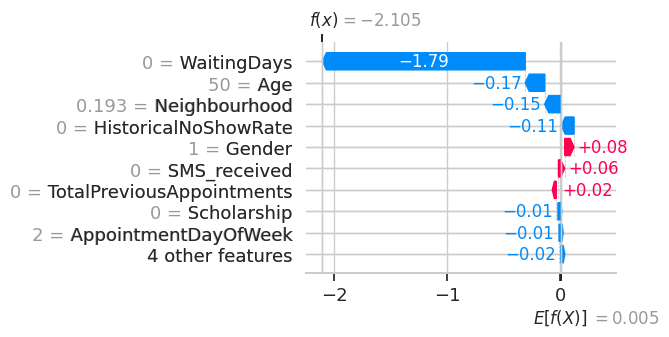


SHAP de Cascata para o Paciente (idx = 1500)


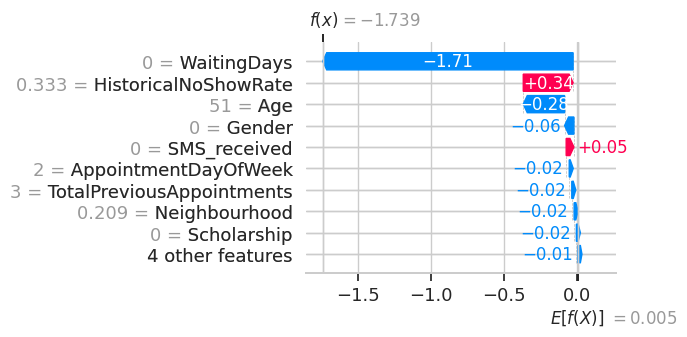

In [129]:
import matplotlib.pyplot as plt

indices = [15, 150, 1500]

for i in indices:
    print(f"\nSHAP de Cascata para o Paciente (idx = {i})")

    explanation = explainer(X_test_shap.iloc[[i]])

    shap.plots.waterfall(explanation[0], show=False)

    plt.gcf().set_size_inches(4, 3)
    plt.show()

Enquanto o SHAP Summary explica o comportamento geral de todos os pacientes, os Gráficos de Cascata (Waterfall) explicam o risco de um **paciente específico**.

# Clusterização

Nossa hipótese é: **Existem perfis comportamentais de pacientes que têm maior propensão a faltar?**

Para testar isso, vamos utilizar o algoritmo **K-Means** para segmentar os pacientes com base em variáveis comportamentais e temporais que foram relevantes na explicabilidade do modelo anterior (como Idade, Tempo de Espera e Histórico de Faltas).

Em seguida, avaliaremos se extrair essa padrão melhora o modelo e, principalmente, se traz alguma relevância para nossa primeira análise.

Analisando o melhor valor de K (isso pode levar um instante)...
K=2 | Silhouette Score: 0.4713
K=3 | Silhouette Score: 0.3218
K=4 | Silhouette Score: 0.3383
K=5 | Silhouette Score: 0.3723
K=6 | Silhouette Score: 0.3860


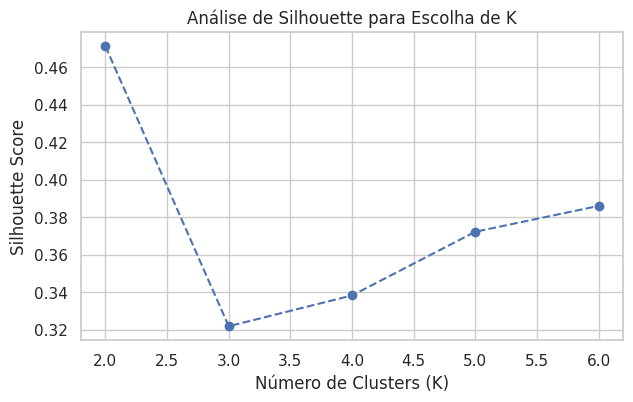


O melhor valor de K encontrado na análise foi: 2
Clusterização concluída e perfis adicionados ao dataset!


In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Garantir que a extração para o cluster seja com os dados transformados
X_train_encoded = best_xgb.named_steps['target_encoder'].transform(X_train)
X_test_encoded = best_xgb.named_steps['target_encoder'].transform(X_test)

# Variáveis que mais demonstraram impacto no SHAP e comportamento do paciente
features_cluster = ['Age', 'WaitingDays', 'HistoricalNoShowRate', 'TotalPreviousAppointments']

scaler = StandardScaler()
X_train_cluster_scaled = scaler.fit_transform(X_train_encoded[features_cluster])
X_test_cluster_scaled = scaler.transform(X_test_encoded[features_cluster])

k_values = range(2, 7)
silhouette_scores = []

print("Analisando o melhor valor de K (isso pode levar um instante)...")
for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_train_cluster_scaled)
    # Usamos uma amostra para evitar estouro de memória (Complexidade O(N^2))
    score = silhouette_score(X_train_cluster_scaled, labels, sample_size=10000, random_state=42)
    silhouette_scores.append(score)
    print(f"K={k} | Silhouette Score: {score:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--', color='b')
plt.title('Análise de Silhouette para Escolha de K')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Selecionar o melhor K baseado no maior Silhouette Score
best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nO melhor valor de K encontrado na análise foi: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

X_train['PatientProfile'] = kmeans.fit_predict(X_train_cluster_scaled)
X_test['PatientProfile'] = kmeans.predict(X_test_cluster_scaled)
print("Clusterização concluída e perfis adicionados ao dataset!")


Centróides


,Age,WaitingDays,HistoricalNoShowRate,TotalPreviousAppointments,Taxa_Falta_Real (%),Qtd_Pacientes
PatientProfile,,,,,,
0,37.05,13.07,0.00,0.47,21.06,75349
1,36.94,8.02,0.66,3.74,29.18,13067


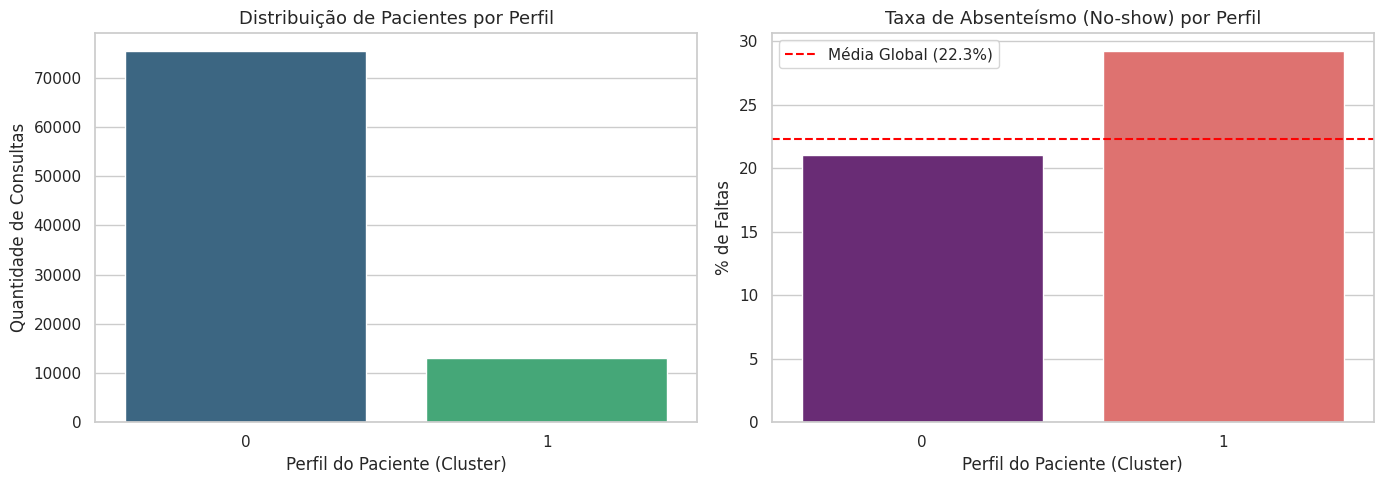

In [131]:
# Agregando os resultados para entender quem é cada cluster
df_train_cluster_analysis = X_train.copy()
df_train_cluster_analysis['No-show'] = y_train

resumo_clusters = df_train_cluster_analysis.groupby('PatientProfile')[features_cluster].mean().round(2)
resumo_clusters['Taxa_Falta_Real (%)'] = (df_train_cluster_analysis.groupby('PatientProfile')['No-show'].mean() * 100).round(2)
resumo_clusters['Qtd_Pacientes'] = df_train_cluster_analysis.groupby('PatientProfile').size()

print("\nCentróides")
display(resumo_clusters)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tamanho dos Clusters
sns.barplot(x=resumo_clusters.index, y='Qtd_Pacientes', data=resumo_clusters, palette='viridis', ax=axes[0], hue=resumo_clusters.index, legend=False)
axes[0].set_title('Distribuição de Pacientes por Perfil', fontsize=13)
axes[0].set_xlabel('Perfil do Paciente (Cluster)')
axes[0].set_ylabel('Quantidade de Consultas')

# Risco de Falta por Cluster
sns.barplot(x=resumo_clusters.index, y='Taxa_Falta_Real (%)', data=resumo_clusters, palette='magma', ax=axes[1], hue=resumo_clusters.index, legend=False)
axes[1].set_title('Taxa de Absenteísmo (No-show) por Perfil', fontsize=13)
axes[1].set_xlabel('Perfil do Paciente (Cluster)')
axes[1].set_ylabel('% de Faltas')

# Adicionando linha base da média global de faltas do Treino
media_global_falta = df_train_cluster_analysis['No-show'].mean() * 100
axes[1].axhline(media_global_falta, color='red', linestyle='--', label=f'Média Global ({media_global_falta:.1f}%)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Inclusão dos Clusters como Atributo

In [132]:
import pandas as pd
from imblearn.pipeline import Pipeline as ImbPipeline
from category_encoders import TargetEncoder
from xgboost import XGBClassifier

# Aplica One-Hot Encoding na variável categórica de Cluster para o modelo
X_train_clustered = pd.get_dummies(X_train, columns=['PatientProfile'], prefix='Cluster', drop_first=False)
X_test_clustered = pd.get_dummies(X_test, columns=['PatientProfile'], prefix='Cluster', drop_first=False)

# Garante que o teste tenha as mesmas colunas que o treino
X_test_clustered = X_test_clustered.reindex(columns=X_train_clustered.columns, fill_value=0)

# Converte as colunas booleanas geradas para inteiro (0 e 1)
for col in X_train_clustered.columns:
    if X_train_clustered[col].dtype == 'bool':
        X_train_clustered[col] = X_train_clustered[col].astype(int)
        X_test_clustered[col] = X_test_clustered[col].astype(int)

y_train_clustered = y_train.copy()
y_test_clustered = y_test.copy()

scale_pos_weight_clustered = (y_train_clustered == 0).sum() / (y_train_clustered == 1).sum()

# Extrai o modelo base do pipeline anterior
xgb_base = best_xgb.named_steps['model']

# Cria um novo modelo XGBoost com os mesmos melhores parâmetros
xgb_clustered_model = XGBClassifier(
    subsample=xgb_base.subsample,
    n_estimators=xgb_base.n_estimators,
    max_depth=xgb_base.max_depth,
    learning_rate=xgb_base.learning_rate,
    colsample_bytree=xgb_base.colsample_bytree,
    random_state=42,
    scale_pos_weight=scale_pos_weight_clustered,
    eval_metric='logloss'
)

# Recria o pipeline com o Target Encoder para lidar com a coluna 'Neighbourhood'
best_xgb_clustered = ImbPipeline([
    ('target_encoder', TargetEncoder(cols=['Neighbourhood'], smoothing=10)),
    ('model', xgb_clustered_model)
])

print("\nAvaliando Best XGBoost com Clustering (K-Fold)... ")
cv_results_clustered = cross_validate(best_xgb_clustered,
                                     X_train_clustered,
                                     y_train_clustered,
                                     cv=cv_compartilhado,
                                     scoring=metricas,
                                     n_jobs=-1)

resultados_cv['Best XGBoost (Cluster)'] = {
    'F1-Score (Macro) Média': cv_results_clustered['test_f1_macro'].mean(),
    'F1-Score (Macro) Std': cv_results_clustered['test_f1_macro'].std(),
    'F1-Score (Classe 1/Faltou) Média': cv_results_clustered['test_f1_classe_1'].mean(),
    'AUC-ROC Média': cv_results_clustered['test_auc_roc'].mean()
}

df_comparacao = pd.DataFrame(resultados_cv).T
df_comparacao = df_comparacao.sort_values(by='AUC-ROC Média', ascending=False)

display(df_comparacao.round(4))


Avaliando Best XGBoost com Clustering (K-Fold)... 


,F1-Score (Macro) Média,F1-Score (Macro) Std,F1-Score (Classe 1/Faltou) Média,AUC-ROC Média
XGBoost (Best),0.5802,0.0304,0.4300,0.7167
Best XGBoost (Cluster),0.5868,0.0157,0.4235,0.7146
Random Forest (Best),0.5938,0.0219,0.3996,0.7110
XGBoost (Base),0.5847,0.0160,0.4039,0.6986
Random Forest (Base),0.5321,0.0038,0.1912,0.6759
Árvore de Decisão,0.5425,0.0137,0.2815,0.5453


Calculando os valores SHAP para o modelo com clustering...

Gráfico gerado e salvo com sucesso em 'assets/shap_summary_clustered.png'!


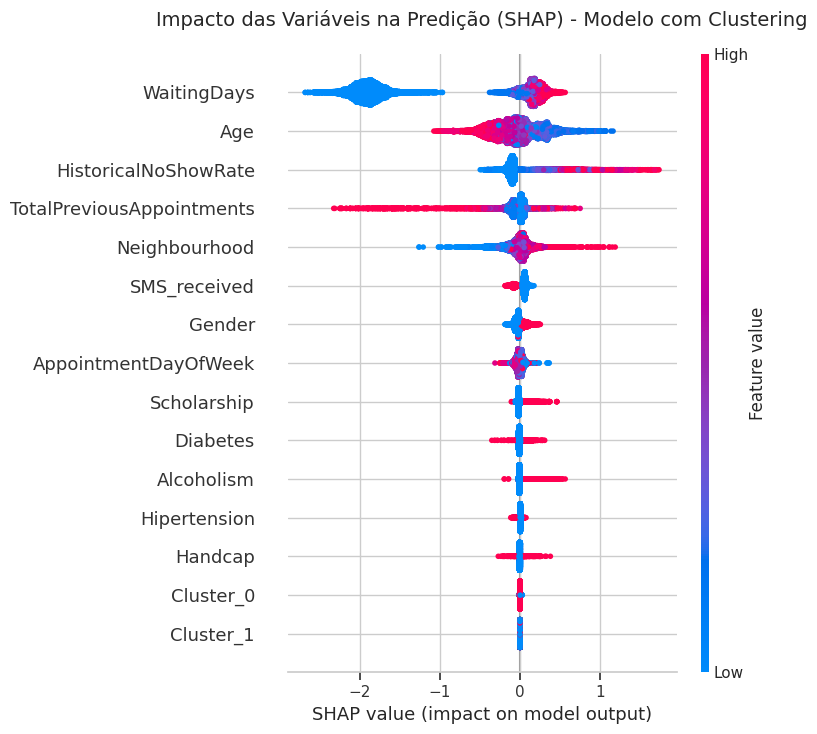

In [133]:
# Treina o modelo clustered no conjunto de treino completo
best_xgb_clustered.fit(X_train_clustered, y_train_clustered)

print("Calculando os valores SHAP para o modelo com clustering...")

modelo_interno_xgb_clustered = best_xgb_clustered.named_steps['model']
target_encoder_clustered = best_xgb_clustered.named_steps['target_encoder']
X_test_clustered_shap = target_encoder_clustered.transform(X_test_clustered)

explainer_clustered = shap.TreeExplainer(modelo_interno_xgb_clustered)
shap_values_clustered = explainer_clustered.shap_values(X_test_clustered_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_clustered, X_test_clustered_shap, show=False)

plt.title('Impacto das Variáveis na Predição (SHAP) - Modelo com Clustering', fontsize=14, pad=20)
plt.tight_layout()

if not os.path.exists('assets'):
    os.makedirs('assets')
plt.savefig('assets/shap_summary_clustered.png', dpi=300, bbox_inches='tight')

print("\nGráfico gerado e salvo com sucesso em 'assets/shap_summary_clustered.png'!")
plt.show()

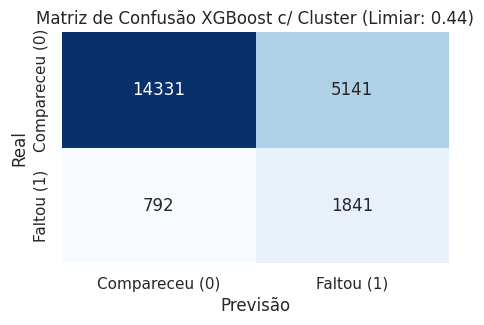

In [134]:
# Preve com o melhor modelo no conjunto de teste usando os dados com cluster e escalonados
y_pred_xgb_best = best_xgb_clustered.predict(X_test_clustered)

cm_xgb_best = confusion_matrix(y_test_clustered, y_pred_xgb_best)

# Recalcula as probabilidades usando o modelo novo
y_pred_proba_clustered = best_xgb_clustered.predict_proba(X_test_clustered)[:, 1]

# Aplica o limiar ótimo encontrado anteriormente nas novas probabilidades
y_pred_optimal = (y_pred_proba_clustered >= optimal_threshold).astype(int)

cm_optimal = confusion_matrix(y_test_clustered, y_pred_optimal)

plt.figure(figsize=(5, 3))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Compareceu (0)', 'Faltou (1)'],
            yticklabels=['Compareceu (0)', 'Faltou (1)'])
plt.title(f'Matriz de Confusão XGBoost c/ Cluster (Limiar: {optimal_threshold:.2f})')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

In [135]:
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
import pandas as pd


f1_macro_clustered_opt = f1_score(y_test_clustered, y_pred_optimal, average='macro')
f1_class1_clustered_opt = f1_score(y_test_clustered, y_pred_optimal, pos_label=1)
roc_auc_clustered_opt = roc_auc_score(y_test_clustered, y_pred_proba_clustered)
pr_auc_clustered_opt = average_precision_score(y_test_clustered, y_pred_proba_clustered)

metricas_clustered_opt = {
    'Métrica': ['F1-Macro', 'F1 Classe 1', 'ROC-AUC', 'PR-AUC'],
    'Score (Cluster + Limiar Ótimo)': [f1_macro_clustered_opt, f1_class1_clustered_opt, roc_auc_clustered_opt, pr_auc_clustered_opt]
}

df_metricas_clustered_opt = pd.DataFrame(metricas_clustered_opt)
display(df_metricas_clustered_opt.round(4))

,Métrica,Score (Cluster + Limiar Ótimo)
0,F1-Macro,0.6057
1,F1 Classe 1,0.3829
2,ROC-AUC,0.7824
3,PR-AUC,0.3199


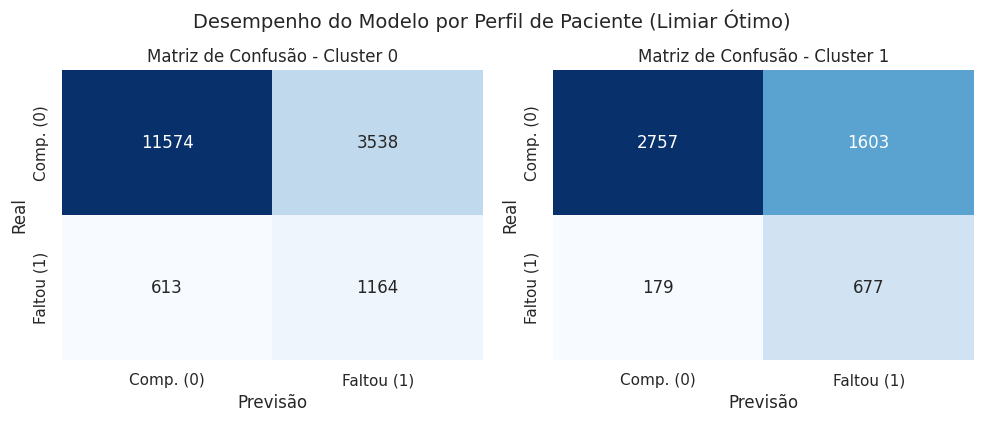

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import math

cols = 2
rows = math.ceil(best_k / cols)

fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows))
axes = np.array(axes).flatten()

for i in range(best_k):
    mask = X_test['PatientProfile'] == i
    y_true_cluster = y_test_clustered[mask]
    y_pred_cluster = y_pred_optimal[mask]  # Usando as previsões com o limiar ajustado

    cm_cluster = confusion_matrix(y_true_cluster, y_pred_cluster)

    sns.heatmap(cm_cluster, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Comp. (0)', 'Faltou (1)'],
                yticklabels=['Comp. (0)', 'Faltou (1)'],
                ax=axes[i])
    axes[i].set_title(f'Matriz de Confusão - Cluster {i}')
    axes[i].set_xlabel('Previsão')
    axes[i].set_ylabel('Real')

for j in range(best_k, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Desempenho do Modelo por Perfil de Paciente (Limiar Ótimo)', y=1.05, fontsize=14)
plt.show()

# Conclusão

## O Impacto da Clusterização

Observando os resultados, percebemos que a clusterização agregou um valor que foi considerado relevante pelo modelo XGBoost Otimizado, mas não houve impacto na métrica de performance do modelo, não superando sua versão sem o uso do Cluster.

A inclusão do `PatientProfile` como uma nova variável pouco altera ou até causa uma variação levíssima na AUC-ROC do modelo. Isso acontece porque o XGBoost, sendo um algoritmo altamente não-linear e profundo, em teoria, já consegue encontrar esses padrões de forma orgânica durante a criação de suas árvores. O K-Means apenas condensa algo que a floresta já "sabe". Então o custo de uma análise não supervisionada não é útil no caso estudado.

Do ponto de vista de interpretação, a clusterização agrega o entendimento dos dados. Ela traduz as probabilidades em grupos identificáveis: Cluster de Baixo Risco e Cluster de Alto Risco